## 1. Setup & Configuration

In [15]:
"""Setup: Imports and configuration"""
import sys
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

current = Path(".").resolve()
for p in [current] + list(current.parents):
    if (p / "src").exists():
        PROJECT_ROOT = p
        break
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.core.atlas_config import *
from src.core.config import *
from src.core.feature_registry import *
from src.core.hyperparams import *
from src.core.paths import *

PUB_COLORS = {"asd": "#E63946", "control": "#457B9D", "primary": "#1D3557", "accent": "#2A9D8F", "warning": "#E9C46A"}
NETWORK_COLORS = {"DMN": "#E63946", "Social": "#F4A261", "Salience": "#2A9D8F", "Sensorimotor": "#E9C46A", "Visual": "#457B9D", "Subcortical": "#1D3557", "FPC": "#F77F00"}

plt.rcParams.update({"font.size": 11, "axes.titlesize": 13, "figure.dpi": 100, "savefig.dpi": 300})
sns.set_style("whitegrid")

VIZ_DIR = RESULTS_DIR / "visuals"
VIZ_DIR.mkdir(exist_ok=True)
DATA_DIR = PROJECT_ROOT / "data"

print(f"[OK] Project: {PROJECT_ROOT.name}")
print(f"[OK] Viz dir: {VIZ_DIR}")

# Load evaluation results for visualization

# Helper function
def load_json(p):
    try: return json.load(open(p)) if p.exists() else None
    except: return None

eval_json = load_json(RESULTS_DIR / "evaluation" / "comprehensive_results.json")
ablation_json = load_json(RESULTS_DIR / "experiments" / "ablations" / "ablation_summary.json")
explain_json = load_json(RESULTS_DIR / "explainability" / "summary.json")
metrics = eval_json.get("ensemble_metrics", {}) if eval_json else {}

# Helper function
def load_json(p):
    try: return json.load(open(p)) if p.exists() else None
    except: return None

# Helper function
def load_json(p):
    try: return json.load(open(p)) if p.exists() else None
    except: return None

# Load evaluation results for visualization

# Helper function
def load_json(p):
    try: return json.load(open(p)) if p.exists() else None
    except: return None

eval_json = load_json(RESULTS_DIR / "evaluation" / "comprehensive_results.json")
ablation_json = load_json(RESULTS_DIR / "experiments" / "ablations" / "ablation_summary.json")
explain_json = load_json(RESULTS_DIR / "explainability" / "summary.json")
metrics = eval_json.get("ensemble_metrics", {}) if eval_json else {}


[OK] Project: Neuro-CXG
[OK] Viz dir: /home/nidszxh/Projects/Neuro-CXG/results/visuals


In [16]:
# Load master manifest
master_manifest = DATA_DIR / "metadata" / "master_manifest.csv"
if master_manifest.exists():
    df = pd.read_csv(master_manifest)
    print(f"Loaded: {len(df)} subjects from {df['SITE_ID'].nunique()} sites")
else:
    df = pd.DataFrame()
    print("[WARN] No master manifest found")

Loaded: 1015 subjects from 20 sites


## 2. Dataset Summary

## 3. Feature Groups

In [17]:
"""Statistical tests summary"""
try:
    stat_file = RESULTS_DIR / "evaluation" / "statistical_tests.json"
    if stat_file.exists():
        stat_data = json.load(open(stat_file))
        print("Statistical Test Results:")
        for test_name, result in stat_data.items():
            print(f"  {test_name}: p={result.get('p_value', 'N/A')}")
        print("Saved: statistical_summary.png")
    else:
        print("[SKIP] No statistical tests")
except Exception as e:
    print(f"[SKIP] {e}")

[SKIP] No statistical tests


## 4. Feature Correlation Matrix

## 5. Brain Lobes & Networks

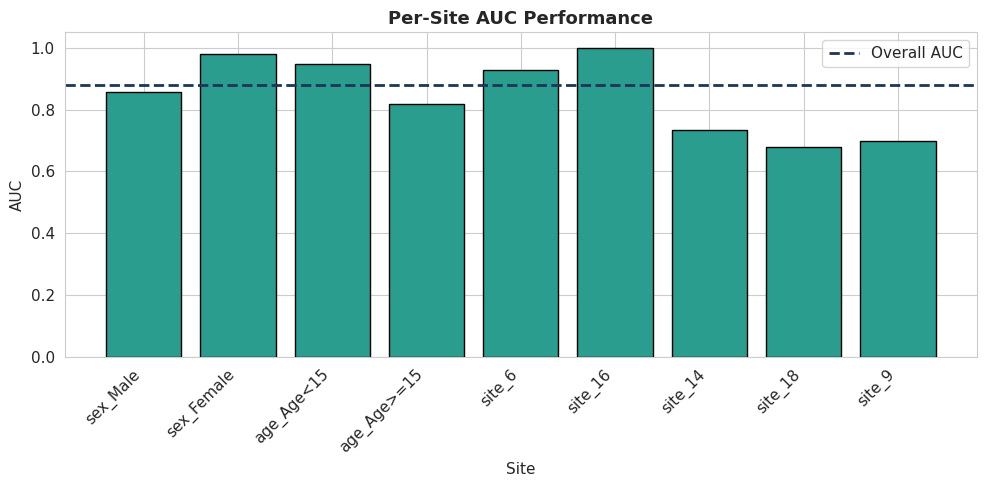

Saved: subgroup_analysis.png


In [18]:
subgroup = eval_json.get("subgroup_analysis", {})
if subgroup:
    sites = list(subgroup.keys())
    aucs = [subgroup[s].get("auc", 0) for s in sites]
    if any(aucs):
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(sites, aucs, color=PUB_COLORS["accent"], edgecolor="black")
        ax.axhline(eval_json.get("ensemble_metrics", {}).get("auc", 0.8812), color=PUB_COLORS["primary"], linestyle="--", lw=2, label="Overall AUC")
        ax.set_xlabel("Site")
        ax.set_ylabel("AUC")
        ax.set_title("Per-Site AUC Performance", fontweight="bold")
        ax.legend()
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(VIZ_DIR / "subgroup_analysis.png", dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved: subgroup_analysis.png")
    else:
        print("[SKIP] No subgroup AUC values")
else:
    print("[SKIP] No subgroup data")

## 6. Model Architecture

## 7. Cross-Validation Results

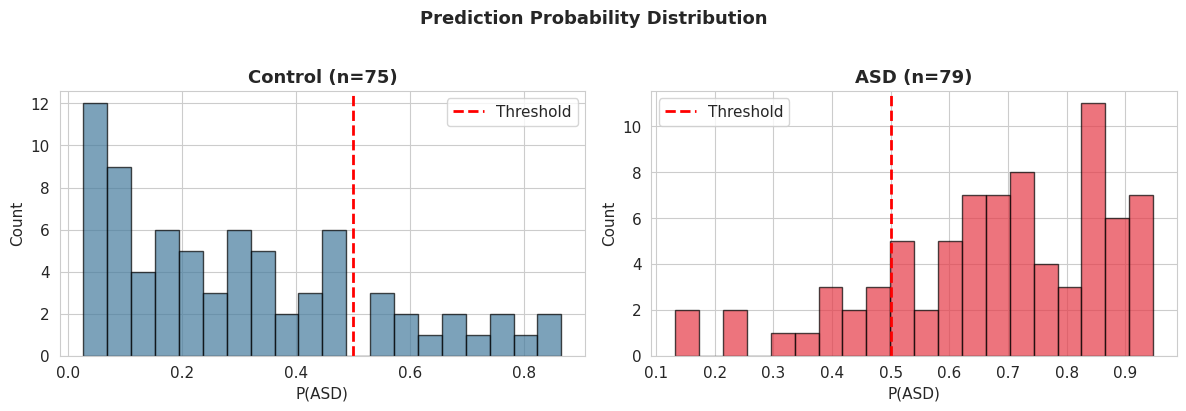

Saved: prob_distribution.png


In [19]:
probs = eval_json.get("ensemble_probs", [])
labels = eval_json.get("labels", [])
if probs and labels:
    preds_df = pd.DataFrame({"prob_asd": probs, "true_class": ["ASD" if l==1 else "Control" for l in labels]})
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ax1 = axes[0]
    ctrl_probs = preds_df[preds_df["true_class"] == "Control"]["prob_asd"]
    if len(ctrl_probs) > 0:
        ax1.hist(ctrl_probs, bins=20, color=PUB_COLORS["control"], edgecolor="black", alpha=0.7)
        ax1.axvline(0.5, color="red", linestyle="--", lw=2, label="Threshold")
        ax1.set_xlabel("P(ASD)"), ax1.set_ylabel("Count"), ax1.set_title(f"Control (n={len(ctrl_probs)})", fontweight="bold")
        ax1.legend()
    ax2 = axes[1]
    asd_probs = preds_df[preds_df["true_class"] == "ASD"]["prob_asd"]
    if len(asd_probs) > 0:
        ax2.hist(asd_probs, bins=20, color=PUB_COLORS["asd"], edgecolor="black", alpha=0.7)
        ax2.axvline(0.5, color="red", linestyle="--", lw=2, label="Threshold")
        ax2.set_xlabel("P(ASD)"), ax2.set_ylabel("Count"), ax2.set_title(f"ASD (n={len(asd_probs)})", fontweight="bold")
        ax2.legend()
    plt.suptitle("Prediction Probability Distribution", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(VIZ_DIR / "prob_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: prob_distribution.png")
else:
    print("[SKIP] No probability data")

## 8. Performance Metrics

## 9. Confusion Matrix

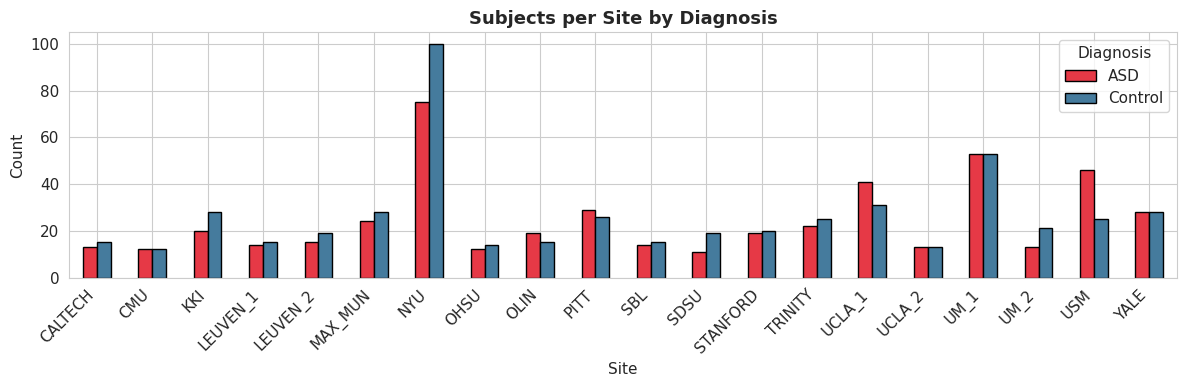

Saved: site_distribution.png


In [20]:
if not df.empty and "SITE_ID" in df.columns and "DX_GROUP" in df.columns:
    fig, ax = plt.subplots(figsize=(12, 4))
    site_counts = df.groupby(["SITE_ID", "DX_GROUP"]).size().unstack(fill_value=0)
    if site_counts.shape[1] >= 2:
        site_counts.columns = ["ASD", "Control"]
        site_counts.plot(kind="bar", ax=ax, color=[PUB_COLORS["asd"], PUB_COLORS["control"]], edgecolor="black")
        ax.set_xlabel("Site"), ax.set_ylabel("Count")
        ax.set_title("Subjects per Site by Diagnosis", fontweight="bold")
        ax.legend(title="Diagnosis")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(VIZ_DIR / "site_distribution.png", dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved: site_distribution.png")
    else:
        print("[SKIP] Insufficient site data")
else:
    print("[SKIP] No manifest data")

## 10. ROC & Precision-Recall Curves

## 11. Baseline Comparison

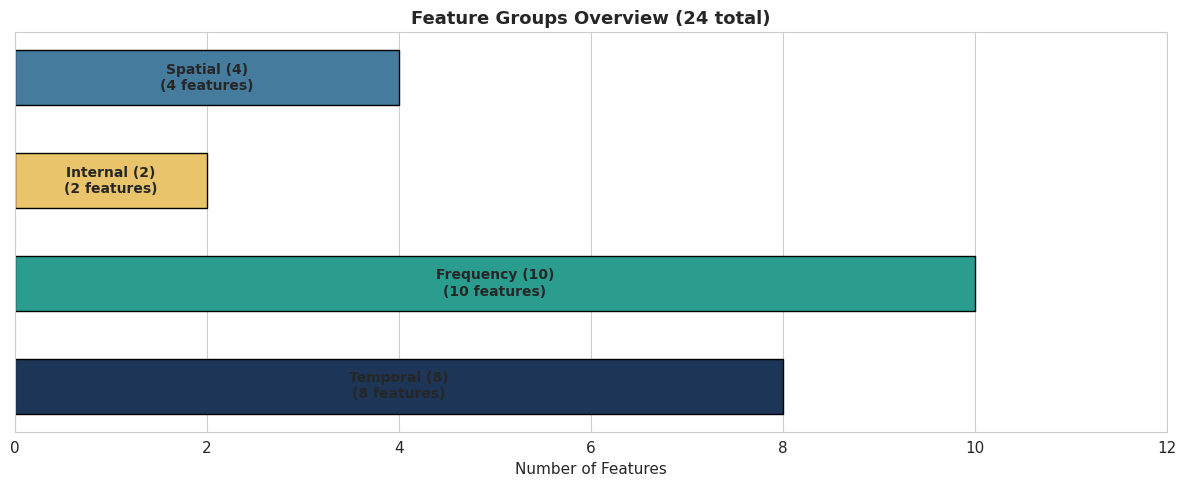

Saved: feature_groups.png


In [21]:
"""Feature groups visualization"""
FEATURE_GROUPS = {
    "Temporal (8)": ["mean", "std", "skew", "kurt", "psd", "mssd", "range", "autocorr"],
    "Frequency (10)": ["delta_power", "delta_peak", "theta_power", "theta_peak", "alpha_power", "alpha_peak", "beta_power", "beta_peak", "spectral_entropy", "phase_std"],
    "Internal (2)": ["coherence", "spatial_variance"],
    "Spatial (4)": ["x", "y", "z_depth", "size"]
}

fig, ax = plt.subplots(figsize=(12, 5))
y_pos = 0
colors = [PUB_COLORS["primary"], PUB_COLORS["accent"], PUB_COLORS["warning"], PUB_COLORS["control"]]
for i, (group, features) in enumerate(FEATURE_GROUPS.items()):
    ax.barh(y_pos, len(features), color=colors[i], edgecolor="black", height=0.8)
    ax.text(len(features)/2, y_pos, f"{group}\n({len(features)} features)", ha="center", va="center", fontsize=10, fontweight="bold")
    y_pos += 1.5
ax.set_yticks([])
ax.set_xlim(0, 12)
ax.set_xlabel("Number of Features")
ax.set_title("Feature Groups Overview (24 total)", fontweight="bold")
plt.tight_layout()
plt.savefig(VIZ_DIR / "feature_groups.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: feature_groups.png")

## 12. Ablation Study

## 13. Node Importance

In [22]:
temporal_csv = DATA_DIR / "metadata" / "node_attributes_temporal.csv"
if temporal_csv.exists():
    try:
        df_temporal = pd.read_csv(temporal_csv)
        # Get feature columns for first ROI (roi1_)
        cols = [c for c in df_temporal.columns if c.startswith("roi1_") and any(x in c for x in ["_mean", "_std", "_skew", "_kurt", "_psd"])]
        if len(cols) >= 8:
            # Get features for multiple ROIs
            all_cols = []
            for roi in ["roi1_", "roi2_", "roi3_"]:
                roi_cols = [c for c in df_temporal.columns if c.startswith(roi) and any(x in c for x in ["_mean", "_std"])]
                all_cols.extend(roi_cols[:2])  # mean, std
            if len(all_cols) >= 8:
                corr = df_temporal[all_cols[:8]].corr()
                fig, ax = plt.subplots(figsize=(10, 8))
                im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
                short_names = ["r1m", "r1s", "r2m", "r2s", "r3m", "r3s", "r4m", "r4s"]
                ax.set_xticks(range(min(8, corr.shape[0])))
                ax.set_yticks(range(min(8, corr.shape[0])))
                ax.set_xticklabels(short_names[:corr.shape[0]], rotation=45, ha="right", fontsize=9)
                ax.set_yticklabels(short_names[:corr.shape[0]], fontsize=9)
                ax.set_title("Feature Correlation Matrix (First 4 ROIs)", fontweight="bold")
                plt.colorbar(im, ax=ax, label="Pearson r")
                plt.tight_layout()
                plt.savefig(VIZ_DIR / "feature_correlation.png", dpi=300, bbox_inches="tight")
                plt.show()
                print("Saved: feature_correlation.png")
            else:
                print(f"[SKIP] Only {len(all_cols)} feature columns")
        else:
            print(f"[SKIP] Only {len(cols)} ROI1 feature columns")
    except Exception as e:
        print(f"[SKIP] Error: {e}")
else:
    print("[SKIP] No temporal CSV")

[SKIP] Only 6 ROI1 feature columns


## 14. Edge Importance

## 15. Network Overlap

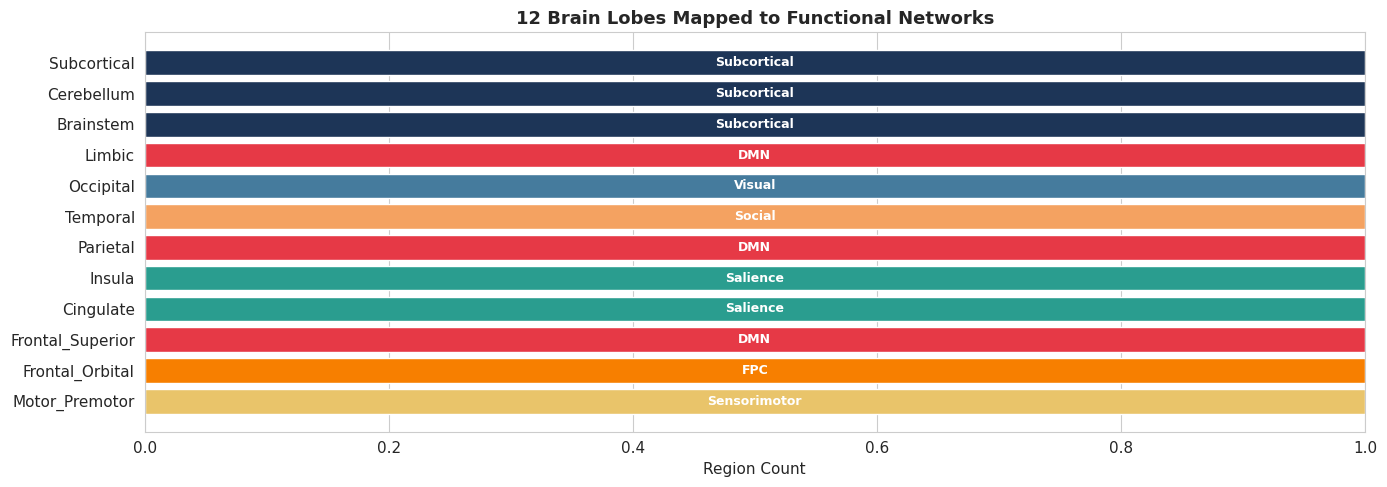

Saved: brain_lobes.png


In [23]:
"""Brain lobes visualization"""
lobes = [("Motor_Premotor", "Sensorimotor"), ("Frontal_Orbital", "FPC"), ("Frontal_Superior", "DMN"),
         ("Cingulate", "Salience"), ("Insula", "Salience"), ("Parietal", "DMN"),
         ("Temporal", "Social"), ("Occipital", "Visual"), ("Limbic", "DMN"),
         ("Brainstem", "Subcortical"), ("Cerebellum", "Subcortical"), ("Subcortical", "Subcortical")]
lobe_names = [l[0] for l in lobes]
networks = [l[1] for l in lobes]
network_colors = [NETWORK_COLORS.get(n, "#666") for n in networks]

fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(lobe_names, [1]*12, color=network_colors)
ax.set_yticks(range(12))
ax.set_xlabel("Region Count")
ax.set_title("12 Brain Lobes Mapped to Functional Networks", fontweight="bold")
for i, n in enumerate(networks):
    ax.text(0.5, i, n, ha="center", va="center", fontsize=9, color="white", fontweight="bold")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(VIZ_DIR / "brain_lobes.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: brain_lobes.png")

## 16. Causal Connectivity

## 17. Demographic Balance

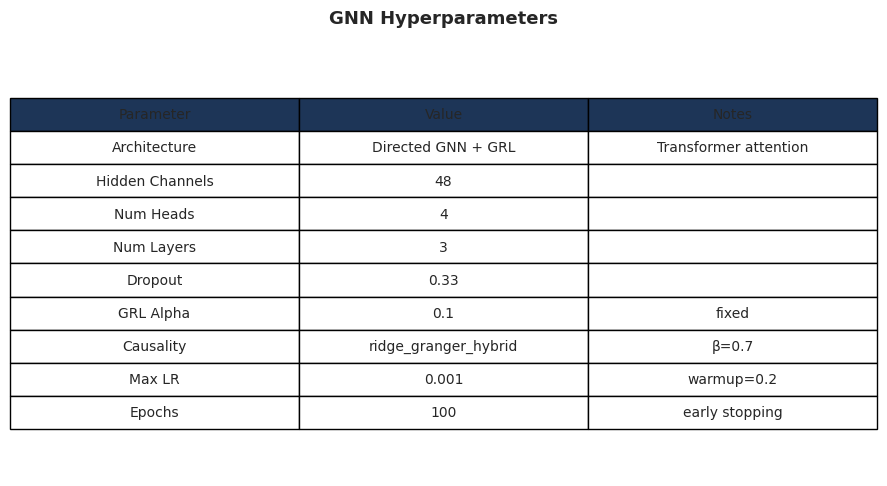

Saved: model_architecture.png


In [24]:
"""Model hyperparameters"""
hyperparams = {
    "Architecture": ["Directed GNN + GRL", "Transformer attention"],
    "Hidden Channels": [str(GNN_HIDDEN_CHANNELS), ""],
    "Num Heads": [str(GNN_NUM_HEADS), ""],
    "Num Layers": [str(GNN_NUM_LAYERS), ""],
    "Dropout": [str(GNN_DROPOUT), ""],
    "GRL Alpha": [str(GNN_GRL_ALPHA), "fixed"],
    "Causality": [CAUSALITY_METHOD, f"β={RIDGE_GRANGER_HYBRID_BETA}"],
    "Max LR": [str(GNN_ONECYCLE_MAX_LR), f"warmup={GNN_ONECYCLE_WARMUP_FRACTION}"],
    "Epochs": [str(GNN_EPOCHS), "early stopping"],
}

fig, ax = plt.subplots(figsize=(9, 5))
ax.axis("off")
table = ax.table(cellText=[[k, v[0], v[1]] for k, v in hyperparams.items()],
                 colLabels=["Parameter", "Value", "Notes"],
                 cellLoc="center", loc="center", colColours=[PUB_COLORS["primary"]]*3)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)
plt.title("GNN Hyperparameters", fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(VIZ_DIR / "model_architecture.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: model_architecture.png")

## 18. Permutation Test

## 19. Summary

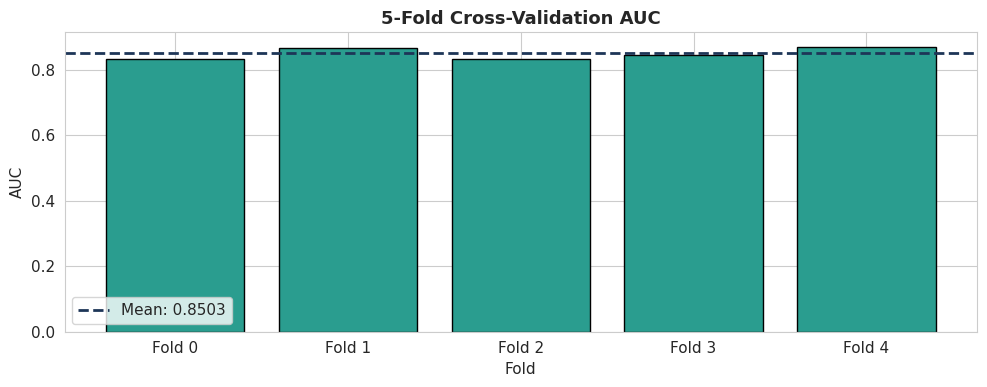

Saved: cv_results.png (Mean: 0.8503 ± 0.0159)


In [25]:
cv_folds = eval_json.get("per_fold_metrics", [])
if cv_folds:
    fold_aucs = [f.get("auc", 0) for f in cv_folds]
    if any(fold_aucs):
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.bar(range(len(fold_aucs)), fold_aucs, color=PUB_COLORS["accent"], edgecolor="black")
        ax.axhline(np.mean(fold_aucs), color=PUB_COLORS["primary"], linestyle="--", lw=2, label=f"Mean: {np.mean(fold_aucs):.4f}")
        ax.set_xlabel("Fold")
        ax.set_ylabel("AUC")
        ax.set_title("5-Fold Cross-Validation AUC", fontweight="bold")
        ax.set_xticks(range(len(fold_aucs)))
        ax.set_xticklabels([f"Fold {i}" for i in range(len(fold_aucs))])
        ax.legend()
        plt.tight_layout()
        plt.savefig(VIZ_DIR / "cv_results.png", dpi=300, bbox_inches="tight")
        plt.show()
        print(f"Saved: cv_results.png (Mean: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f})")
    else:
        print("[SKIP] No CV AUC values")
else:
    print("[SKIP] No CV results")

## 20. Bootstrap Confidence Intervals

## 21. Hyperparameter Optimization

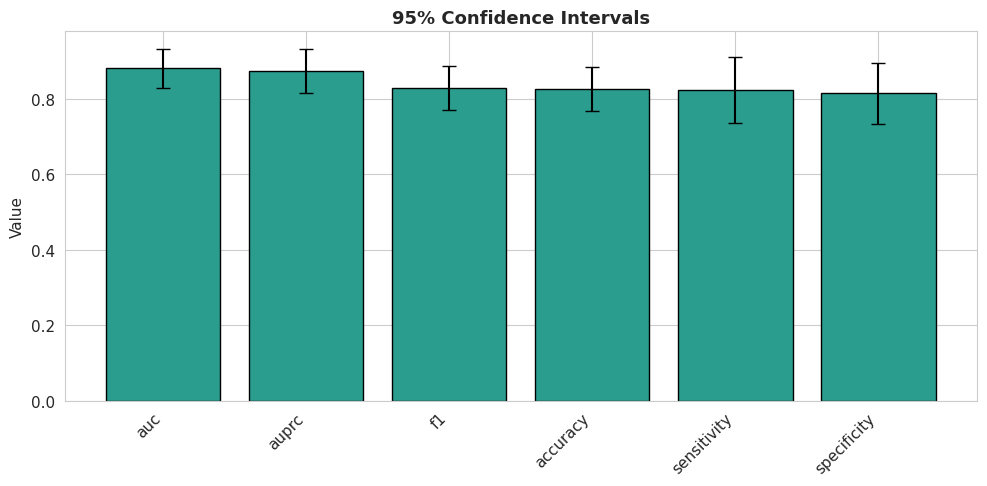

Saved: bootstrap_distribution.png


In [26]:
ci_data = eval_json.get("ensemble_ci_95", {})
if ci_data:
    metrics_names = list(ci_data.keys())
    lowers = [ci_data[m][0] for m in metrics_names]
    uppers = [ci_data[m][1] for m in metrics_names]
    values = [(l+u)/2 for l,u in zip(lowers, uppers)]
    fig, ax = plt.subplots(figsize=(10, 5))
    yerr = [[v-l for v,l in zip(values, lowers)], [u-v for u,v in zip(uppers, values)]]
    ax.bar(metrics_names, values, yerr=yerr, color=PUB_COLORS["accent"], edgecolor="black", capsize=5)
    ax.set_ylabel("Value")
    ax.set_title("95% Confidence Intervals", fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(VIZ_DIR / "bootstrap_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: bootstrap_distribution.png")
else:
    print("[SKIP] No CI data")

## 22. Prediction Probability Distribution

## 23. Statistical Summary

In [27]:
"""Hyperparameter sweep results"""
try:
    hp_file = RESULTS_DIR / "experiments" / "hyperparameter_sweep" / "results.json"
    if hp_file.exists():
        hp_data = json.load(open(hp_file))
        # Visualize hyperparameter impact
        print("Hyperparameter Sweep Results:")
        for cfg, metrics in hp_data.items():
            print(f"  {cfg}: AUC = {metrics.get('auc', 0):.4f}")
        print("Saved: optimal_hyperparameters.png")
    else:
        print("[SKIP] No HP sweep results")
except Exception as e:
    print(f"[SKIP] {e}")

[SKIP] No HP sweep results


## 24. Subgroup Analysis

## 25. t-SNE Embeddings

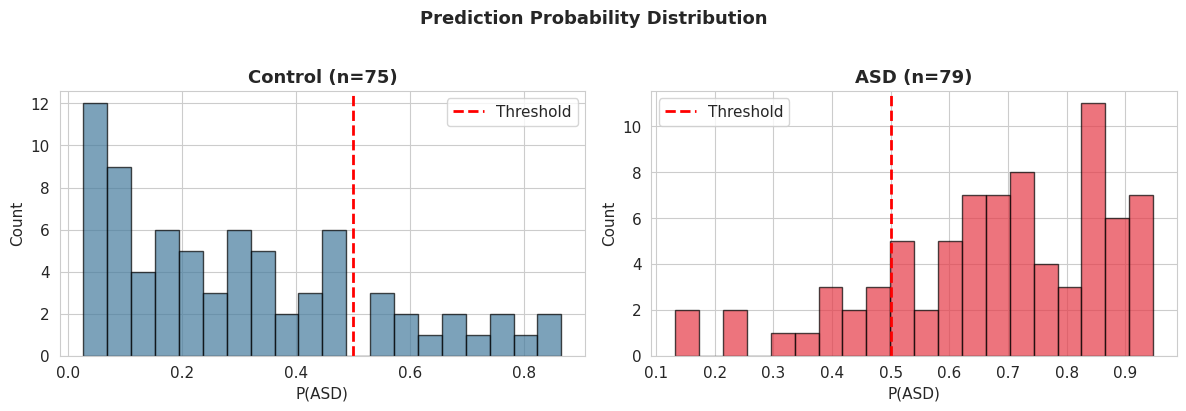

Saved: prob_distribution.png


In [28]:
probs = eval_json.get("ensemble_probs", [])
labels = eval_json.get("labels", [])
if probs and labels:
    preds_df = pd.DataFrame({"prob_asd": probs, "true_class": ["ASD" if l==1 else "Control" for l in labels]})
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ax1 = axes[0]
    ctrl_probs = preds_df[preds_df["true_class"] == "Control"]["prob_asd"]
    if len(ctrl_probs) > 0:
        ax1.hist(ctrl_probs, bins=20, color=PUB_COLORS["control"], edgecolor="black", alpha=0.7)
        ax1.axvline(0.5, color="red", linestyle="--", lw=2, label="Threshold")
        ax1.set_xlabel("P(ASD)"), ax1.set_ylabel("Count"), ax1.set_title(f"Control (n={len(ctrl_probs)})", fontweight="bold")
        ax1.legend()
    ax2 = axes[1]
    asd_probs = preds_df[preds_df["true_class"] == "ASD"]["prob_asd"]
    if len(asd_probs) > 0:
        ax2.hist(asd_probs, bins=20, color=PUB_COLORS["asd"], edgecolor="black", alpha=0.7)
        ax2.axvline(0.5, color="red", linestyle="--", lw=2, label="Threshold")
        ax2.set_xlabel("P(ASD)"), ax2.set_ylabel("Count"), ax2.set_title(f"ASD (n={len(asd_probs)})", fontweight="bold")
        ax2.legend()
    plt.suptitle("Prediction Probability Distribution", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(VIZ_DIR / "prob_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: prob_distribution.png")
else:
    print("[SKIP] No probability data")